# SALES AND REVENUE

## Business Case

1. Bagaimana tren revenue bulanan dan apakah ada seasonality?
2. Kategori produk mana yang menghasilkan revenue tertinggi?
3. Berapa kontribusi freight value terhadap total revenue per kategori?

## IMPORT LIBRARY 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/products_dataset.csv')
name_translate_product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/product_category_name_translation.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
product.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order
2. tabel order_items : 1 row mempresentasikan item dalam sebuah order
3. tabel products : 1 row mempresentasikan 1 product

### KEY COLUMNS

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `order_status` → status order
   - `order_purchase_timestamp` → waktu saat customer melakukan order

2. **Tabel `order_items`**:
   - `order_id` → identifier order, digunakan untuk menghubungkan `order_items` dengan `orders`
   - `product_id` → identifier product, digunakan untuk menghubungkan `order_items` dengan `products`
   - `price` → harga item
   - `freight_value` → nilai freight/pengiriman

3. **Tabel `products`**:
   - `product_id` → identifier untuk setiap product
   - `product_category_name` → kategori product

### RELATIONSHIP TABEL 

- Tabel `orders` dan `order_items` terhubung melalui `order_id`.
- Tabel `order_items` dan `products` terhubung melalui `product_id`.

- `orders` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu order dapat memiliki beberapa item.
- `products` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu product dapat muncul pada beberapa order item.

## DATA QUALITY

### ASESSING DATA

In [6]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [7]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [8]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [9]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


np.int64(0)

In [10]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [11]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [12]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [13]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


np.int64(0)

In [14]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [15]:
product.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [16]:
print('Checking null value')
product.isna().sum()

Checking null value


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

1.  Untuk kolom ```product_category_name```,```product_name_lenght```,```product_description_lenght```,``` product_photos_qty```,```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'``` terdapat missing value

In [17]:
print('Checking duplicated value')
product.duplicated().sum()

Checking duplicated value


np.int64(0)

### CLEANING DATA

#### MENGUBAH DI TABEL PRODUCT NAMA PRODUCT YANG NULL MENJADI UNKOWN + 5 HURUF TERAKHIR PRODUCT ID 

In [18]:
product['product_category_name'] = product['product_category_name'].fillna(
    'unkown_' + product['product_id'].str[-5:])

#### MENGISI KOLOM NAME LENGTH, DESCRIPTION LENGHT, DAN PHOTOS QTY DENGAN 0

In [19]:
product['product_name_lenght'] = product['product_name_lenght'].fillna(0)
product['product_description_lenght'] = product['product_description_lenght'].fillna(0)
product['product_photos_qty'] = product['product_photos_qty'].fillna(0)

In [20]:
print('Jumlah missing value setelah dilakukan penanganan')
product.isna().sum()

Jumlah missing value setelah dilakukan penanganan


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

**DATA QUALITY NOTE**

Terdapat 2 product yang missing value pada kolom ```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'```, nilai ini tetap dipertahankan karena tidak ada dasar yang dapat dibuat acuan untuk melakukan imputasi

#### TRANSLATE PRODUCT CATEGORY NAME

In [21]:
translate = name_translate_product.set_index('product_category_name')['product_category_name_english']
product['product_category_name'] = product['product_category_name'].map(translate).fillna(product['product_category_name'])

## DATA PREPARATION

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [22]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### MELAKUKAN FILTER TABEL ORDER DENGAN ORDER_STATUS = DELIVERED

In [23]:
order = order[order['order_status'] == 'delivered']

### JOIN TABEL

In [24]:
#JOIN TABEL ORDER DAN ORDER_ITEMS
orders_items = pd.merge(
    left = order_items,
    right = order,
    how = 'left',
    on = 'order_id'
)

In [25]:
#JOIN TABEL ORDER, ORDER_ITEMS DAN PRODUCT
orders_items_products = pd.merge(
    left = orders_items,
    right = product,
    how = 'left',
    on = 'product_id'
)

In [26]:
orders_items_products.isna().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                      2453
order_status                     2453
order_purchase_timestamp         2453
order_approved_at                2468
order_delivered_carrier_date     2455
order_delivered_customer_date    2461
order_estimated_delivery_date    2453
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
dtype: int64

**DATA QUALITY NOTE**
1. Setelah di filter dengan order_status = delivered seharusnya sudah tidak ada missing value dan semua kolom terisi, akan tetapi masih terdapat missing value pada kolom  ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```
2. Tidak dilakukan imputasi atau penghapusan missing value pada tahap ini karena kolom tersebut tidak digunakan dalam analisis Sales & Revenue.
3. Missing value tersebut menjadi keterbatasan data yang perlu diperhatikan apabila dataset digunakan untuk analisis terkait proses dan durasi pengiriman.

### MENAMBAH FEATURE BULAN-TAHUN

In [27]:
#MENGAMBIL BULAN DAN TAHUN SAJA DARI KOLOM order_purchase_timestamp
orders_items_products['tahun_bulan'] = orders_items_products['order_purchase_timestamp'].dt.to_period('M')
orders_items_products

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,tahun_bulan
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,2017-09
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,2017-04
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,2017-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,2018-05-18,housewares,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,2018-04
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,2018-08-01,computers_accessories,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,2018-07
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,...,2017-11-10,sports_leisure,43.0,869.0,1.0,967.0,21.0,24.0,19.0,2017-10
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,...,2017-08-25,computers_accessories,56.0,1306.0,1.0,100.0,20.0,20.0,20.0,2017-08


## EXPLORATORY DATA ANALYSIS

### 1. Bagaimana tren revenue bulanan dan apakah ada seasonality?

In [28]:
revenue_bulanan = orders_items_products[['tahun_bulan','price','order_id']]

In [29]:
tren_revenue_bulanan = revenue_bulanan.groupby(by='tahun_bulan').agg({'order_id' : 'nunique','price' : 'sum' }).sort_values(by='tahun_bulan', ascending=True).reset_index()
tren_revenue_bulanan

,tahun_bulan,order_id,price
0,2016-09,1,134.97
1,2016-10,265,40325.11
2,2016-12,1,10.90
3,2017-01,750,111798.36
4,2017-02,1653,234223.40
5,2017-03,2546,359198.85
6,2017-04,2303,340669.68
7,2017-05,3546,489338.25
8,2017-06,3135,421923.37
9,2017-07,3872,481604.52


##### DATA QUALITY NOTE
Berdasarkan revenue, aktivitas transaksi di tahun 2016 tidak konsisten dibanding tahun berikutnya,namun nilai revenue jika dibandingkan dengan jumlah order, aktivitas transaksi mulai konsisten sejak tahun 2017

In [30]:
#MENAMBAH KOLOM GROWTH_PCT
tren_revenue_bulanan['growth_pct_100'] = tren_revenue_bulanan['price'].pct_change().fillna(0).round(4) *100 
tren_revenue_bulanan

,tahun_bulan,order_id,price,growth_pct_100
0,2016-09,1,134.97,0.00
1,2016-10,265,40325.11,29777.09
2,2016-12,1,10.90,-99.97
3,2017-01,750,111798.36,1025573.03
4,2017-02,1653,234223.40,109.51
5,2017-03,2546,359198.85,53.36
6,2017-04,2303,340669.68,-5.16
7,2017-05,3546,489338.25,43.64
8,2017-06,3135,421923.37,-13.78
9,2017-07,3872,481604.52,14.15


In [31]:
#MENGGANTI NAMA KOLOM
tren_revenue_bulanan = tren_revenue_bulanan.rename(columns={
    'price': 'Total Revenue',
    'order_id': 'Total Order',
    'tahun_bulan': 'Periode'
    }
)                                 
tren_revenue_bulanan

,Periode,Total Order,Total Revenue,growth_pct_100
0,2016-09,1,134.97,0.00
1,2016-10,265,40325.11,29777.09
2,2016-12,1,10.90,-99.97
3,2017-01,750,111798.36,1025573.03
4,2017-02,1653,234223.40,109.51
5,2017-03,2546,359198.85,53.36
6,2017-04,2303,340669.68,-5.16
7,2017-05,3546,489338.25,43.64
8,2017-06,3135,421923.37,-13.78
9,2017-07,3872,481604.52,14.15


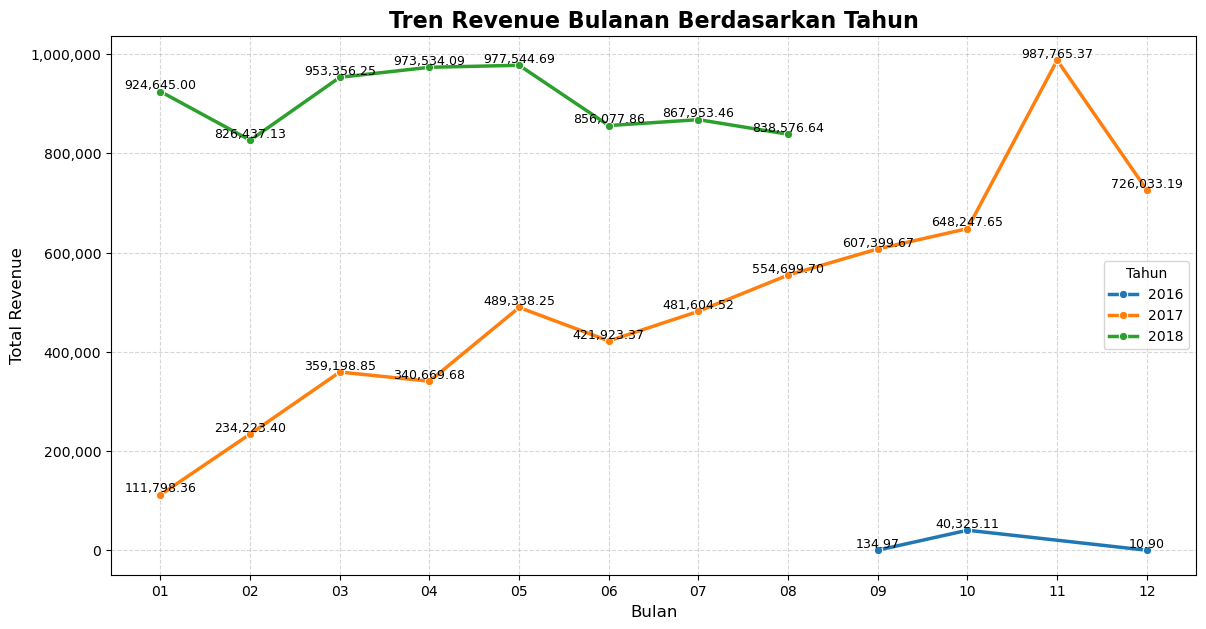

In [32]:
# Mengambil 4 karakter pertama sebagai 'tahun' (contoh: '2023')
tren_revenue_bulanan['tahun'] = tren_revenue_bulanan['Periode'].astype(str).str[:4]

# Mengambil 2 karakter terakhir sebagai 'bulan' (contoh: '01')
tren_revenue_bulanan['bulan'] = tren_revenue_bulanan['Periode'].astype(str).str[-2:]

# MENGURUTKAN DATA DARI BULAN 01 - 12
tren_revenue_bulanan = tren_revenue_bulanan.sort_values(by='bulan')

plt.figure(figsize=(14, 7)) 

# Membuat Line Chart
sns.lineplot(
    data=tren_revenue_bulanan, 
    x='bulan', 
    y='Total Revenue', 
    hue='tahun', 
    hue_order=['2016', '2017', '2018'], 
    marker='o',
    linewidth=2.5
)

# Menambahkan label angka PENUH di setiap titik dengan pemisah ribuan (koma)
for index, row in tren_revenue_bulanan.iterrows():
    plt.text(
        x=row['bulan'], 
        y=row['Total Revenue'], 
        s=f"{row['Total Revenue']:,.2f}",  
        ha='center',               
        va='bottom',               
        fontsize=9,                
        color='black'              
    )

# Mengatur format sumbu Y agar tidak 1e6 dan menampilkan koma
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Tren Revenue Bulanan Berdasarkan Tahun', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

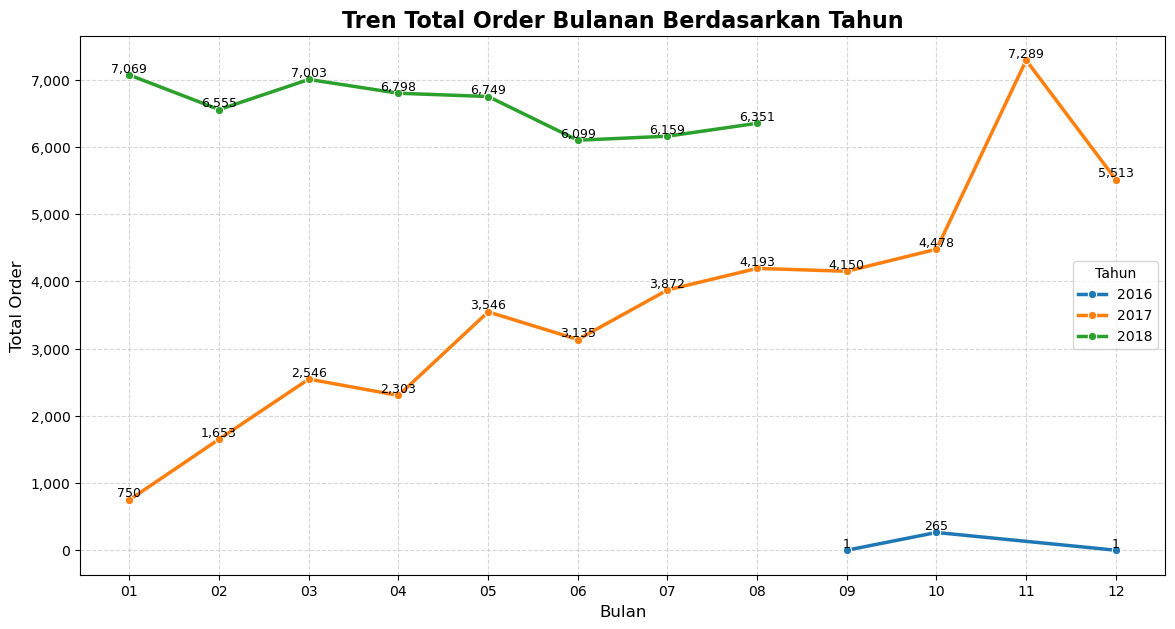

In [33]:
# MENGURUTKAN DATA DARI BULAN 01 - 12
tren_revenue_bulanan = tren_revenue_bulanan.sort_values(by='bulan')

plt.figure(figsize=(14, 7)) 

# Membuat Line Chart
sns.lineplot(
    data=tren_revenue_bulanan, 
    x='bulan', 
    y='Total Order', 
    hue='tahun', 
    hue_order=['2016', '2017', '2018'], 
    marker='o',
    linewidth=2.5
)

# Menambahkan label angka PENUH di setiap titik dengan pemisah ribuan (koma)
for index, row in tren_revenue_bulanan.iterrows():
    plt.text(
        x=row['bulan'], 
        y=row['Total Order'], 
        s=f"{row['Total Order']:,.0f}",  
        ha='center',               
        va='bottom',               
        fontsize=9,                
        color='black'              
    )

# Mengatur format sumbu Y agar tidak 1e6 dan menampilkan koma
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Tren Total Order Bulanan Berdasarkan Tahun', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Order', fontsize=12)
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### KEY INSIGHT

1. Revenue menunjukkan peningkatakan yang signifikan sejak tahun 2017, sejalan dengan pertumbuhan jumlah order
2. Terdapat beberapa kperiode ketika jumlah order turun tetapi revenue meningkat, yaitu di bulan September tahun 2017 dan April-Mei di tahun 2018
3. Revenue dan jumlah order tertinggi tercatat pada November 2017 

### 2. Kategori produk mana yang menghasilkan revenue tertinggi?

In [34]:
kategori_produk = orders_items_products[['order_id','price','product_category_name']]
kategori_produk_revenue = kategori_produk.groupby(by='product_category_name').agg({'order_id' : 'nunique','price' : 'sum' }).sort_values(by='product_category_name', ascending=True).reset_index()
kategori_produk_revenue

,product_category_name,order_id,price
0,agro_industry_and_commerce,182,72530.47
1,air_conditioning,253,55024.96
2,art,202,24202.64
3,arts_and_craftmanship,23,1814.01
4,audio,350,50688.50
...,...,...,...
678,unkown_fde62,1,11.90
679,unkown_fea75,1,36.90
680,unkown_fecd8,1,64.90
681,unkown_ffbde,2,36.98


In [35]:
# MENGHITUNG REVENUE PCT
grand_total = kategori_produk_revenue['price'].sum()
kategori_produk_revenue['revenue_pct'] = ((kategori_produk_revenue['price'] / grand_total) *100).round(4)
kategori_produk_revenue = kategori_produk_revenue.sort_values(by='revenue_pct', ascending=False)

In [36]:
kategori_produk_revenue.head(10)

,product_category_name,order_id,price,revenue_pct
43,health_beauty,8836,1258681.34,9.2607
682,watches_gifts,5624,1205005.68,8.8658
7,bed_bath_table,9417,1036988.68,7.6296
67,sports_leisure,7720,988048.97,7.2695
15,computers_accessories,6689,911954.32,6.7097
39,furniture_decor,6449,729762.49,5.3692
20,cool_stuff,3632,635290.85,4.6741
49,housewares,5884,632248.66,4.6517
5,auto,3897,592720.11,4.3609
42,garden_tools,3518,485256.46,3.5703


In [37]:
kategori_produk_revenue = kategori_produk_revenue.rename(columns={
    'price': 'Total Revenue',
    'order_id': 'Total Order',
    }
)

In [38]:
kategori_produk_revenue.head(10)

,product_category_name,Total Order,Total Revenue,revenue_pct
43,health_beauty,8836,1258681.34,9.2607
682,watches_gifts,5624,1205005.68,8.8658
7,bed_bath_table,9417,1036988.68,7.6296
67,sports_leisure,7720,988048.97,7.2695
15,computers_accessories,6689,911954.32,6.7097
39,furniture_decor,6449,729762.49,5.3692
20,cool_stuff,3632,635290.85,4.6741
49,housewares,5884,632248.66,4.6517
5,auto,3897,592720.11,4.3609
42,garden_tools,3518,485256.46,3.5703


C:\Users\adien\AppData\Local\Temp\ipykernel_16748\678035834.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


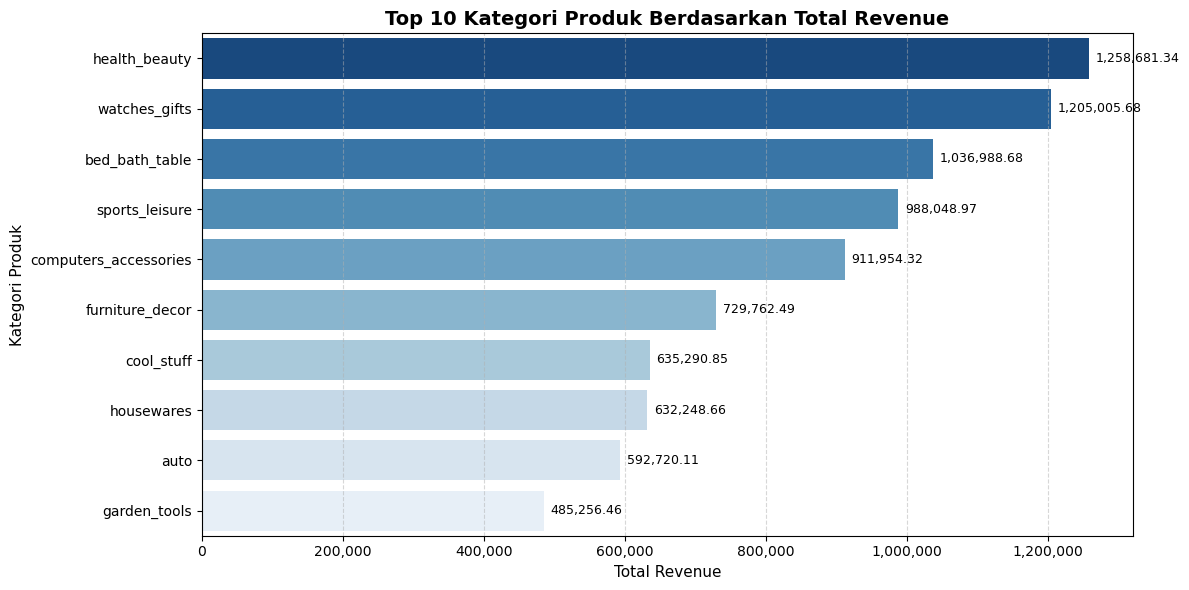

In [39]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10 = kategori_produk_revenue.sort_values(by='Total Revenue', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10,
    x='Total Revenue',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

C:\Users\adien\AppData\Local\Temp\ipykernel_16748\2855863322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


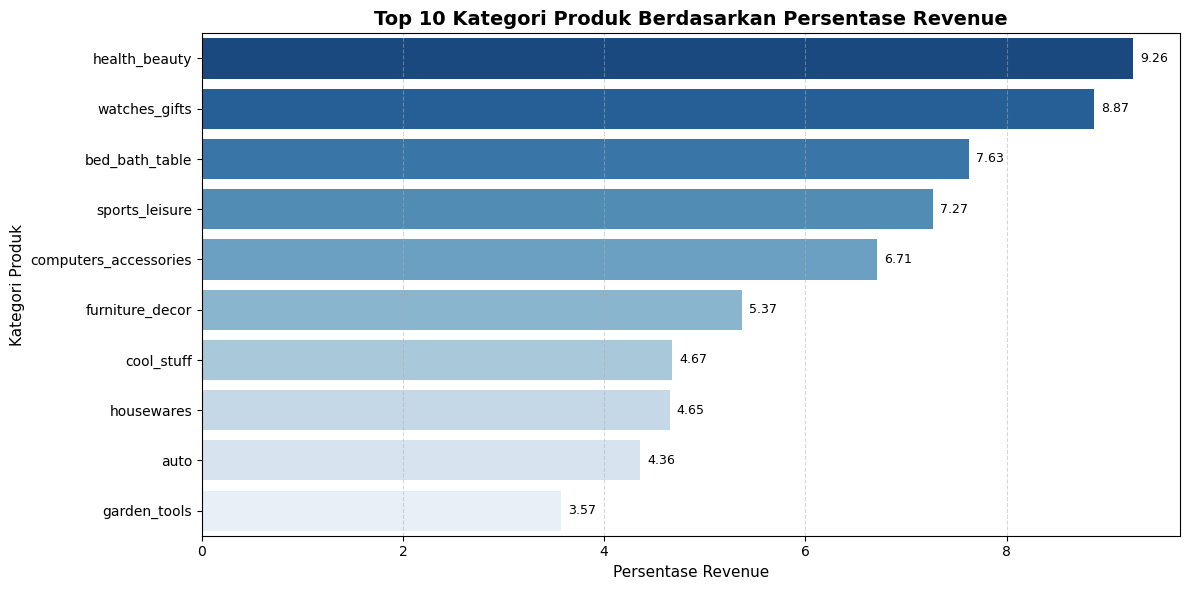

In [40]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10 = kategori_produk_revenue.sort_values(by='Total Revenue', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10,
    x='revenue_pct',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Persentase Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Persentase Revenue', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

#### KEY INSIGHT

1. Produk **health_beauty** menghasilkan revenue tertinggi dengan total revenue **1.258.681,34** dengan kontribusi sebesar **9,27%** dari total keseluruhan revenue
2. Produk **watches_gifts** menghasilkan revenue tertinggi kedua dengan total revenue **1.205.005,68** dengan kontribusi sebesar **8,87%** dari total keseluruhan revenue

### 3. Berapa kontribusi freight value terhadap total revenue per kategori?

In [41]:
freight_revenue = orders_items_products[['product_category_name','freight_value','price','order_id']]

In [42]:
freight_revenue_total = freight_revenue.groupby('product_category_name').agg({
    'order_id' : 'nunique',
    'price' : 'sum',
    'freight_value' : 'sum'
}).reset_index()
freight_revenue_total

,product_category_name,order_id,price,freight_value
0,agro_industry_and_commerce,182,72530.47,5843.60
1,air_conditioning,253,55024.96,6749.23
2,art,202,24202.64,4045.17
3,arts_and_craftmanship,23,1814.01,370.13
4,audio,350,50688.50,5710.44
...,...,...,...,...
678,unkown_fde62,1,11.90,7.39
679,unkown_fea75,1,36.90,38.53
680,unkown_fecd8,1,64.90,15.89
681,unkown_ffbde,2,36.98,22.04


In [43]:
#FRIEGHT_PCT_OF_REVENUE
freight_revenue_total['freight_pct_of_revenue'] = (freight_revenue_total['freight_value']/freight_revenue_total['price'] * 100).round(2) 
freight_revenue_total.sort_values(by=['freight_pct_of_revenue'], ascending = False).head(10)

,product_category_name,order_id,price,freight_value,freight_pct_of_revenue
72,unkown_00475,2,6.00,28.02,467.00
135,unkown_1a8e6,1,22.90,98.02,428.03
211,unkown_397ad,1,4.85,15.10,311.34
587,unkown_d59f9,2,33.46,102.85,307.38
178,unkown_2bad0,1,6.99,21.15,302.58
189,unkown_2f78f,1,5.20,15.10,290.38
132,unkown_1a29a,1,3.90,10.96,281.03
119,unkown_143c1,1,16.00,30.46,190.38
573,unkown_d02f4,1,6.80,12.79,188.09
182,unkown_2ce2f,1,9.00,16.79,186.56


Produk dengan kategori yang tidak tersedia tetap dipertahankan dalam dataset, tetapi tidak digunakan untuk membandingkan freight-to-revenue antar kategori yang diketahui karena identitas kategorinya tidak tersedia dan rasio pada nilai transaksi yang sangat kecil dapat menghasilkan persentase yang ekstrem.

In [44]:
freight_revenue_total_clean = freight_revenue_total[~freight_revenue_total['product_category_name'].str.contains('unkown', na=False)].sort_values(by=['freight_pct_of_revenue'], ascending = False).head(10)

In [45]:
freight_revenue_total_clean = freight_revenue_total_clean.rename(columns={
    'price': 'Total Revenue',
    'order_id': 'Total Order',
    'freight_pct_of_revenue' : 'Persentase Biaya Pengiriman'
}
)

In [46]:
freight_revenue_total_clean

,product_category_name,Total Order,Total Revenue,freight_value,Persentase Biaya Pengiriman
46,home_comfort_2,24,760.27,410.31,53.97
35,flowers,29,1110.04,488.87,44.04
41,furniture_mattress_and_upholstery,38,4368.08,1630.46,37.33
12,christmas_supplies,128,8800.82,3229.30,36.69
23,diapers_and_hygiene,27,1567.59,573.68,36.60
11,cds_dvds_musicals,12,730.00,224.99,30.82
64,signaling_and_security,140,21509.23,6507.82,30.26
37,food_drink,227,15179.48,4507.99,29.70
26,electronics,2550,160246.74,46578.32,29.07
32,fashion_sport,27,2119.51,578.13,27.28


C:\Users\adien\AppData\Local\Temp\ipykernel_16748\3218140034.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


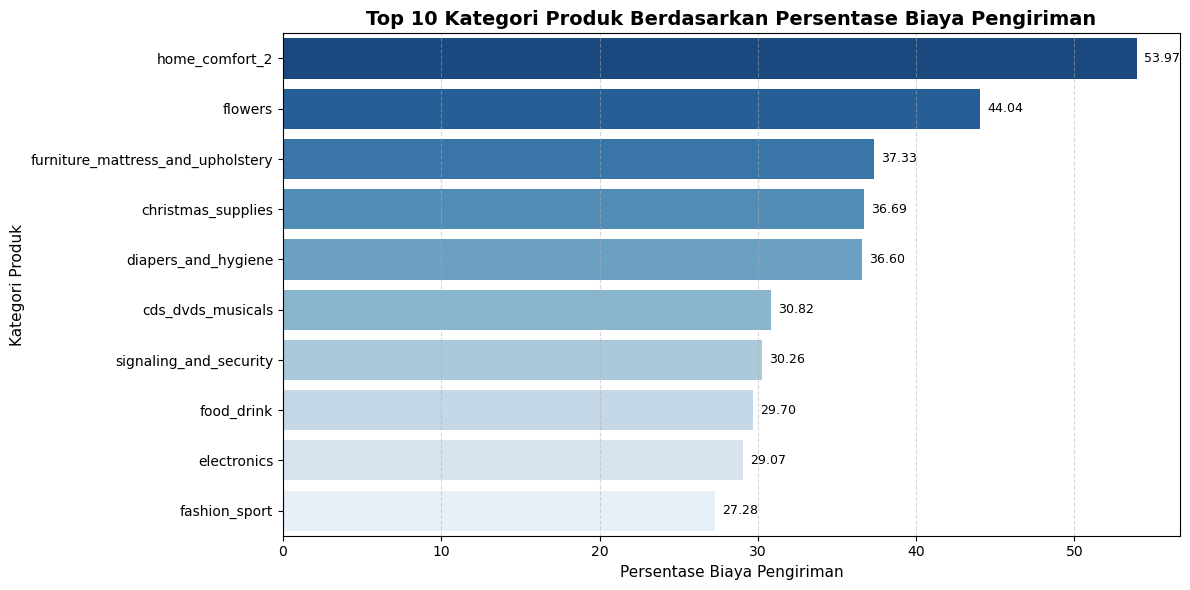

In [47]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10 = freight_revenue_total_clean.sort_values(by='Persentase Biaya Pengiriman', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10,
    x='Persentase Biaya Pengiriman',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Persentase Biaya Pengiriman', fontsize=14, fontweight='bold')
plt.xlabel('Persentase Biaya Pengiriman', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

1. Produk **home_comfort_2** mempunyai persentase fright terhadap revenue tertinggi sebesar  **53,97%** dari total revenue 
2. Produk **flowers** mempunyai persentase fright terhadap revenue tertinggi kedua sebesar **44,04%** dari total revenue 

#### KEY INSIGHT

## KEY FINDINGS

1. Revenue dan volume order menunjukkan pertumbuhan dari tahun 2017
2. Kategori dengan total revenue yang tinggi tidak selalu diikuti dengan tinggi nya freight-to-revenue ratio yang tinggi
3. Terdapat kategori dengan beban freight yang relatif tinggi, yaitu lebih dari 50% dari total revenue

## BUSINESS IMPLICATIONS

1. Pertumbuhan order dan revenue menunjukkan peningkatan aktivitas penjualan, sehingga perkembangan performa antar periode perlu dipantau
2. Beberapa kategori memberikan kontribusi yang cukup besar terhadap total revenue, sehingga perubahan performa kategori tersebut dapat mempengaruhi total revenue
3. Perbedaan ratio freight to revenue antar kategori menunjukkan bahwa total revenue dan total order tidak cukup untuk menggbmbarkan beban pengiriman
4. Kategori dengan ratio freight to revenue tinggi perlu diperhatikan karena freight mengambil porsi yang lebih besar terhadap revenue yang dihasilkan.

In [51]:
orders_items_products.to_csv('sales and revenue.csv', index=False)